In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.model_selection import cross_val_score, cross_validate, learning_curve
from sklearn.pipeline import Pipeline

import seaborn as sns

### Zadanie 13

In [87]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, n_classes=2, weights=[0.95, 0.05], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(class_weight='balanced', max_iter=10000).fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

report = classification_report(y_test, y_pred)
print(f'Wyniki niezbalansowane:\n {report}')


Wyniki niezbalansowane:
               precision    recall  f1-score   support

           0       0.99      0.76      0.86       188
           1       0.18      0.83      0.29        12

    accuracy                           0.76       200
   macro avg       0.58      0.79      0.57       200
weighted avg       0.94      0.76      0.82       200



In [88]:
thresholds = np.linspace(0.1,0.9,9)
prob_preds = model.predict_proba(X_test_scaled)
scores = {}
for t in thresholds:
    pred = prob_preds[:,1] > t
    scores[t] = {'Precision': precision_score(y_test, pred, zero_division=0), 'Recall': recall_score(y_test, pred, zero_division=0), 'F1': f1_score(y_test, pred, zero_division=0)}

df = pd.DataFrame(scores).transpose()
df_filtered = df.loc[(df['Precision'] > 0.5)]
df_filtered = df_filtered.loc[df_filtered['Recall'] == df_filtered['Recall'].max()]
df_filtered

,Precision,Recall,F1


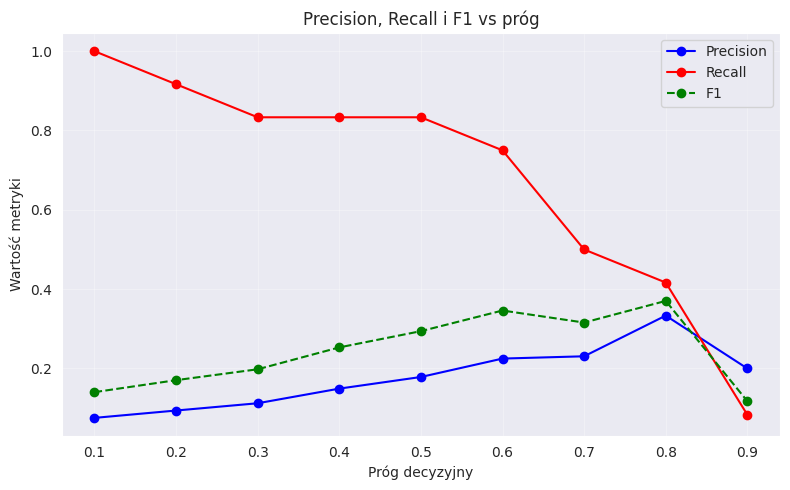

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(df.index, df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(df.index, df['Recall'],    marker='o', label='Recall',    color='red')
plt.plot(df.index, df['F1'],        marker='o', label='F1',        color='green', linestyle='--')
plt.xlabel('Próg decyzyjny')
plt.ylabel('Wartość metryki')
plt.title('Precision, Recall i F1 vs próg')
plt.xticks(df.index)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Zadanie 16

In [146]:
bc = load_breast_cancer()
X, y = bc.data, bc.target

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

scoring = ['accuracy', 'precision', 'recall', 'f1']

result_cvs = {}
raw_cvs = {}
for x in scoring:
    score = cross_val_score(pipeline, X, y, cv=cv, scoring=x)
    raw_cvs[x] = score
    result_cvs[x] = {'avg': np.mean(score), 'std': np.std(score)}

df_cvs = pd.DataFrame(result_cvs).transpose()
df_cvs['+/-'] = df_cvs['avg'] - df_cvs['std']
df_cvs

,avg,std,+/-
accuracy,0.973669,0.016627,0.957041
precision,0.968254,0.028983,0.939272
recall,0.991588,0.011248,0.980340
f1,0.979434,0.012725,0.966709


In [147]:
result_cv = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)

raw_cv = {m: result_cv[f'test_{m}'] for m in scoring}
result_cv = {k: {'avg': np.mean(v), 'std': np.std(v)} for k, v in result_cv.items()}

df_cv = pd.DataFrame(result_cv).iloc[:,2:]
df_cv.columns = df_cv.columns.str.replace('test_', '')
df_cv = df_cv.transpose()
df_cv['+/-'] = df_cv['avg'] - df_cv['std']
df_cv

,avg,std,+/-
accuracy,0.973669,0.016627,0.957041
precision,0.968254,0.028983,0.939272
recall,0.991588,0.011248,0.980340
f1,0.979434,0.012725,0.966709


/tmp/ipykernel_5146/1412773111.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


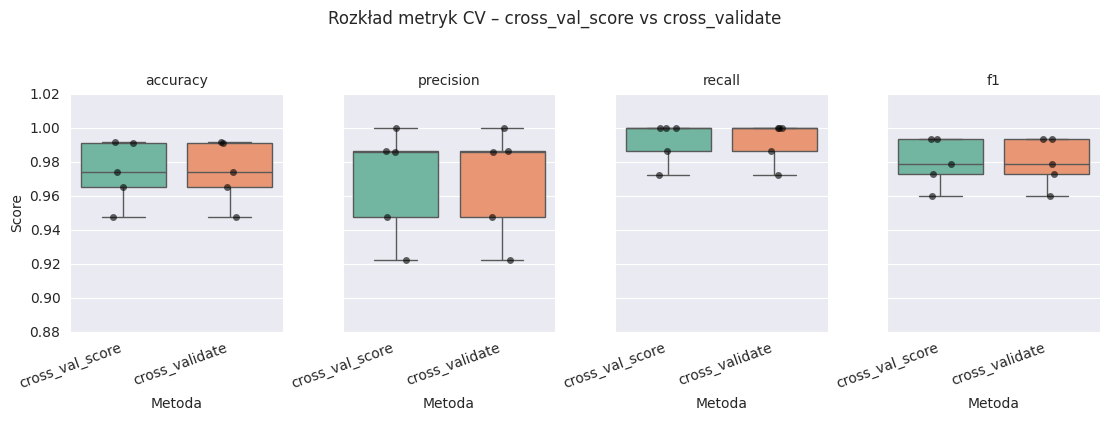

In [150]:
rows = []
for metric in scoring:
    for val in raw_cvs[metric]:
        rows.append({'Metryka': metric, 'Metoda': 'cross_val_score', 'Score': val})
    for val in raw_cv[metric]:
        rows.append({'Metryka': metric, 'Metoda': 'cross_validate', 'Score': val})
df_long = pd.DataFrame(rows)

g = sns.catplot(
    data=df_long,
    x='Metoda', y='Score',
    col='Metryka',
    kind='box',
    height=4, aspect=0.7,
    palette='Set2',
)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Score')
g.set_xticklabels(rotation=20, ha='right')

for ax in g.axes.flat:
    ax.set_ylim(0.88, 1.02)
    subset = df_long[df_long['Metryka'] == ax.get_title()]
    sns.stripplot(data=subset, x='Metoda', y='Score', ax=ax, color='black', size=5, alpha=0.6)

g.figure.suptitle('Rozkład metryk CV – cross_val_score vs cross_validate', y=1.04)
plt.tight_layout()
plt.show()

### Zadanie 18

In [152]:
#validation score = test score
train_sizes, train_scores, val_scores = learning_curve(pipeline, X, y, cv=cv, scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores,  axis=1)
val_mean   = np.mean(val_scores,   axis=1)
val_std    = np.std(val_scores,    axis=1)

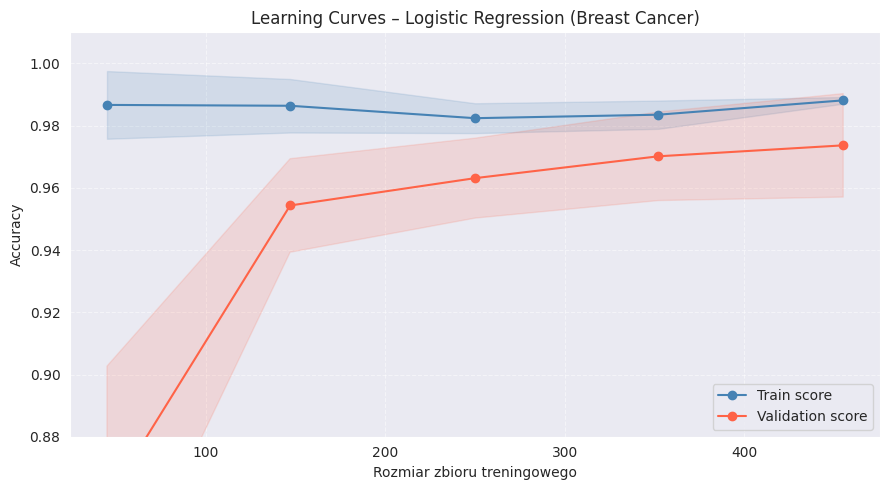

In [155]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')

ax.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validation score')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='tomato')

ax.set_xlabel('Rozmiar zbioru treningowego')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves – Logistic Regression (Breast Cancer)')
ax.legend(loc='lower right')
ax.set_ylim(0.88, 1.01)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()